In [1]:
import numpy as np
import matplotlib.pyplot as plt

# define constants and cosmological models

In [2]:
#constants
c = 3e5 #speed of light in km/s
H0 = 70 #Hubble constant in km/s/Mpc
D_H = c/H0 #Hubble distance in Mpc

#cosmological models (Omega_m, Omega_Lambda, Omega_k, label)
models = [
    
    (0.30, 0.00, 0.70, r'$\Omega_m=0.3,\ \Omega_\Lambda=0.0,\ \Omega_k=0.7$'),
    (1.00, 0.00, 0.00, r'$\Omega_m=1.0,\ \Omega_\Lambda=0.0,\ \Omega_k=0.0$'),
    (0.25, 0.75, 0.00, r'$\Omega_m=0.25,\ \Omega_\Lambda=0.75,\ \Omega_k=0.0$'),
    
]

# define functions

In [3]:
def E(z, Om, OL, Ok):
    return np.sqrt(Om*(1 + z)**3 + Ok*(1 + z)**2 + OL)

In [4]:
def comoving_distance(z, Om, OL, Ok, N = 1000):
    
    if z == 0:
        return 0.
    
    dz = z / N
    z_mids = (np.arange(N) + 0.5) * dz #midpoints
    
    #approximate integral
    integral = np.sum(1.0 / E(z_mids, Om, OL, Ok)) * dz
    
    return D_H * integral

In [5]:
def transverse_comoving(DC, Ok):
    
    if Ok > 0:
        return D_H / np.sqrt(Ok) * np.sinh(np.sqrt(Ok) * DC / D_H)
    
    elif Ok == 0:
        return DC
    
    elif Ok < 0:
        return D_H / np.sqrt(abs(Ok)) * np.sin(np.sqrt(abs(Ok)) * DC / D_H)

In [6]:
#redshift array
z_arr = np.linspace(0.01, 5, 300)

# plotting

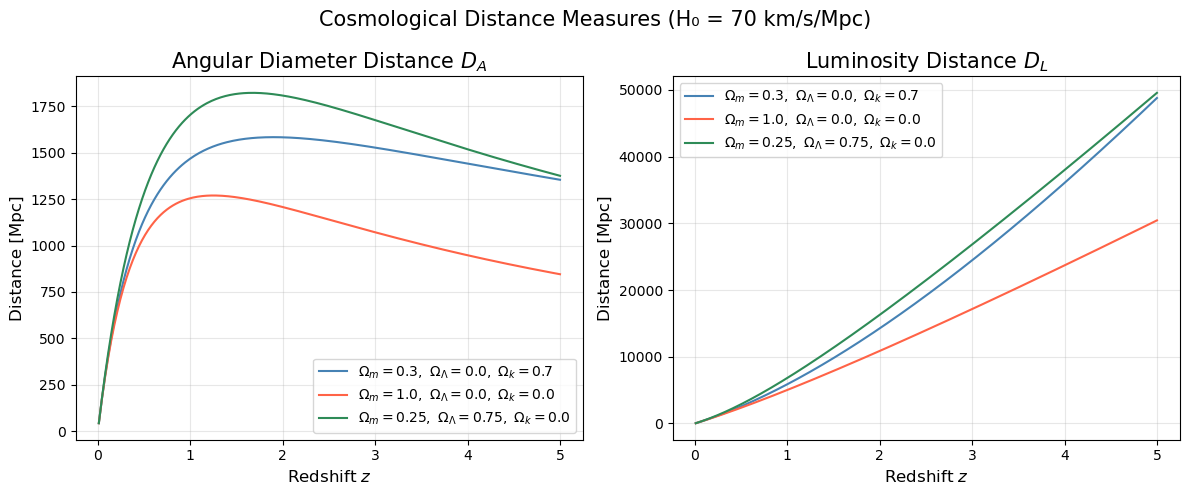

In [7]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
colors = ['steelblue', 'tomato', 'seagreen']

for (Om, OL, Ok, label), color in zip(models, colors):
    
    DA_vals, DL_vals = [], []
    
    for z in z_arr:
        
        DC = comoving_distance(z, Om, OL, Ok)
        DM = transverse_comoving(DC, Ok)
        
        DA_vals.append(DM / (1 + z))
        DL_vals.append((1 + z) * DM)
        
    axes[0].plot(z_arr, DA_vals, label = label, color = color)
    axes[1].plot(z_arr, DL_vals, label = label, color = color)
    
for ax, title in zip(axes, ['Angular Diameter Distance $D_A$', 'Luminosity Distance $D_L$']):
    
    ax.set_title(title, fontsize = 15)
    
    ax.set_xlabel('Redshift $z$', fontsize = 12)
    ax.set_ylabel('Distance [Mpc]', fontsize = 12)
    
    ax.legend(fontsize = 10)
    ax.grid(True, alpha = 0.3)
    
plt.suptitle('Cosmological Distance Measures (H₀ = 70 km/s/Mpc)', fontsize = 15)
plt.tight_layout()

plt.savefig('Distance_Measures.png', dpi = 150)